# Human Activity Recognition from Smartphone Sensor Features

## Goal

This notebook builds a supervised machine learning model to classify human activities using smartphone sensor features.

The task is to predict the activity being performed from accelerometer and gyroscope-based features.

The possible activities are:

- Walking
- Walking upstairs
- Walking downstairs
- Sitting
- Standing
- Laying

## Main techniques

This notebook uses:

- supervised multi-class classification
- subject-aware train/validation/test splitting
- high-dimensional sensor features
- baseline comparison
- logistic regression
- PCA + logistic regression
- tree-based classification
- confusion matrix analysis
- per-class F1-score analysis
- feature importance analysis

In [1]:
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")
dataset_path = Path(dataset_path)

print("Dataset downloaded to:", dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))
csv_files

100%|██████████| 24.5M/24.5M [00:04<00:00, 5.72MB/s]

Extracting files...


Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\uciml\human-activity-recognition-with-smartphones\versions\2


[WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/uciml/human-activity-recognition-with-smartphones/versions/2/test.csv'),
 WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/uciml/human-activity-recognition-with-smartphones/versions/2/train.csv')]

In [3]:
train_csv = None
test_csv = None

for file in csv_files:
    if file.name.lower() == "train.csv":
        train_csv = file
    elif file.name.lower() == "test.csv":
        test_csv = file

print("Train CSV:", train_csv)
print("Test CSV:", test_csv)

Train CSV: C:\Users\ADMIN\.cache\kagglehub\datasets\uciml\human-activity-recognition-with-smartphones\versions\2\train.csv
Test CSV: C:\Users\ADMIN\.cache\kagglehub\datasets\uciml\human-activity-recognition-with-smartphones\versions\2\test.csv


In [4]:
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 44.3 MB


## Data loading 

The train and test CSV files were combined into one full dataset.

The combined dataset contains 10,299 rows and 563 columns. Each row represents one smartphone sensor window. The dataset includes 561 numerical sensor features, one subject identifier, and one activity label.

This combined version allows the notebook to create a new subject-aware split instead of relying on the original train/test split.

In [6]:
target_col = "Activity"
subject_col = "subject"

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Unique subjects:", df[subject_col].nunique())
print("Activity classes:", df[target_col].nunique())

Rows: 10299
Columns: 563
Unique subjects: 30
Activity classes: 6


In [7]:
df[target_col].value_counts()

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

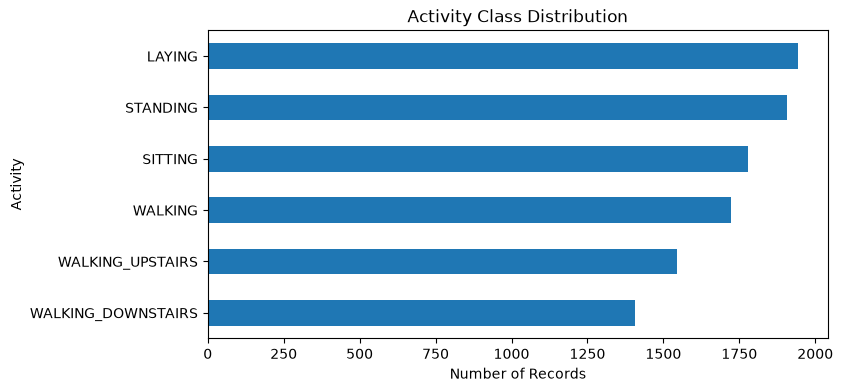

In [8]:
activity_counts = df[target_col].value_counts()

plt.figure(figsize=(8, 4))
activity_counts.sort_values().plot(kind="barh")
plt.title("Activity Class Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Activity")
plt.show()

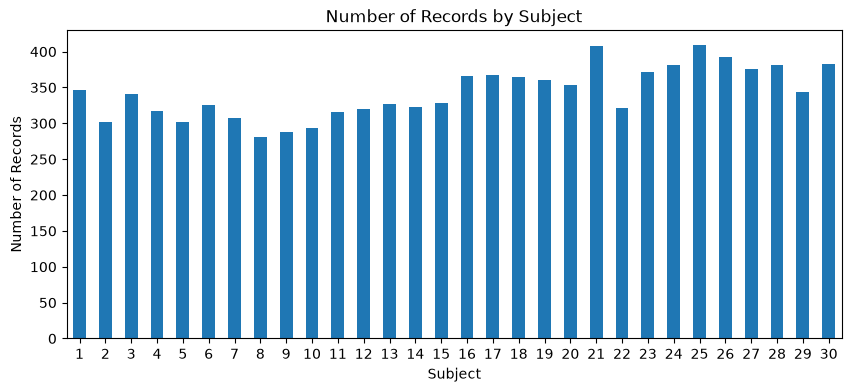

In [9]:
subject_counts = df[subject_col].value_counts().sort_index()

plt.figure(figsize=(10, 4))
subject_counts.plot(kind="bar")
plt.title("Number of Records by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

# Basic inspection 

The dataset contains 30 unique subjects and 6 activity classes.

The class distribution is fairly balanced:

- LAYING: 1,944 records
- STANDING: 1,906 records
- SITTING: 1,777 records
- WALKING: 1,722 records
- WALKING_UPSTAIRS: 1,544 records
- WALKING_DOWNSTAIRS: 1,406 records

The dataset is suitable for multi-class classification because every activity has a reasonable number of examples.

In [10]:
X = df.drop(columns=[target_col, subject_col])
y = df[target_col]
groups = df[subject_col]

X = X.apply(pd.to_numeric, errors="coerce")

print("Feature matrix:", X.shape)
print("Target:", y.shape)
print("Groups:", groups.shape)

Feature matrix: (10299, 561)
Target: (10299,)
Groups: (10299,)


In [12]:
class_order = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

class_order = [label for label in class_order if label in y.unique()]

class_order

['WALKING',
 'WALKING_UPSTAIRS',
 'WALKING_DOWNSTAIRS',
 'SITTING',
 'STANDING',
 'LAYING']

## Feature preparation 

The feature matrix contains 10,299 rows and 561 numerical sensor features.

The target variable is the activity label, while the subject column is used only for group-based splitting.

The subject column was not included as a model feature because that could allow the model to memorise subject-specific patterns instead of learning general activity patterns.

In [13]:
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_train_val = X.iloc[train_val_idx].copy()
y_train_val = y.iloc[train_val_idx].copy()
groups_train_val = groups.iloc[train_val_idx].copy()

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_test = groups.iloc[test_idx].copy()

In [14]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx_rel, val_idx_rel = next(
    gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
)

X_train = X_train_val.iloc[train_idx_rel].copy()
y_train = y_train_val.iloc[train_idx_rel].copy()
groups_train = groups_train_val.iloc[train_idx_rel].copy()

X_val = X_train_val.iloc[val_idx_rel].copy()
y_val = y_train_val.iloc[val_idx_rel].copy()
groups_val = groups_train_val.iloc[val_idx_rel].copy()

In [15]:
groups_val = groups_train_val.iloc[val_idx_rel].copy()
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain subjects:", sorted(groups_train.unique()))
print("Validation subjects:", sorted(groups_val.unique()))
print("Test subjects:", sorted(groups_test.unique()))

print("\nSubject overlap checks:")
print("Train ∩ Validation:", set(groups_train).intersection(set(groups_val)))
print("Train ∩ Test:", set(groups_train).intersection(set(groups_test)))
print("Validation ∩ Test:", set(groups_val).intersection(set(groups_test)))

Train shape: (6138, 561)
Validation shape: (2086, 561)
Test shape: (2075, 561)

Train subjects: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(13), np.int64(15), np.int64(17), np.int64(19), np.int64(20), np.int64(22), np.int64(25), np.int64(26), np.int64(27), np.int64(29), np.int64(30)]
Validation subjects: [np.int64(1), np.int64(11), np.int64(12), np.int64(14), np.int64(21), np.int64(23)]
Test subjects: [np.int64(9), np.int64(10), np.int64(16), np.int64(18), np.int64(24), np.int64(28)]

Subject overlap checks:
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [16]:
split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "subjects": [
        groups_train.nunique(),
        groups_val.nunique(),
        groups_test.nunique()
    ]
})

split_summary

,split,rows,subjects
0,Train,6138,18
1,Validation,2086,6
2,Test,2075,6


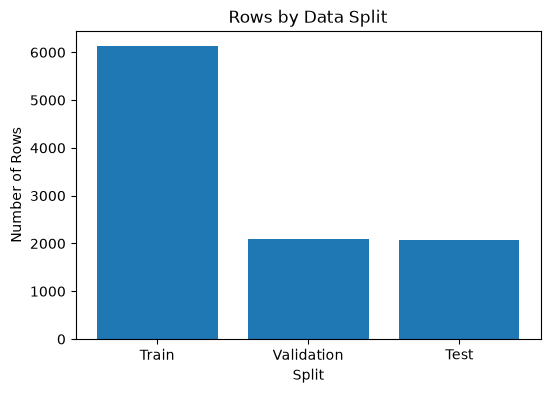

In [17]:
plt.figure(figsize=(6, 4))
plt.bar(split_summary["split"], split_summary["rows"])
plt.title("Rows by Data Split")
plt.xlabel("Split")
plt.ylabel("Number of Rows")
plt.show()

## Subject-aware split 

The data was split by subject instead of randomly splitting individual rows.

The final split was:

- Training set: 6,138 rows from 18 subjects
- Validation set: 2,086 rows from 6 subjects
- Test set: 2,075 rows from 6 subjects

There was no subject overlap between the training, validation, and test sets.

This makes the evaluation more realistic because the model is tested on people it has not seen during training.

In [18]:
split_activity_df = pd.concat([
    pd.DataFrame({"split": "Train", "activity": y_train}),
    pd.DataFrame({"split": "Validation", "activity": y_val}),
    pd.DataFrame({"split": "Test", "activity": y_test})
])

split_activity_counts = (
    split_activity_df
    .groupby(["split", "activity"])
    .size()
    .reset_index(name="count")
)

split_activity_counts.head()

,split,activity,count
0,Test,LAYING,395
1,Test,SITTING,370
2,Test,STANDING,388
3,Test,WALKING,324
4,Test,WALKING_DOWNSTAIRS,283


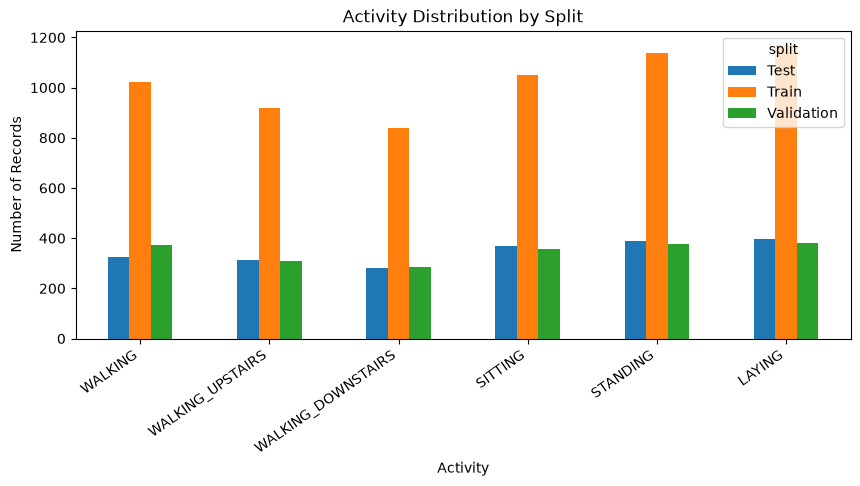

In [19]:
pivot_counts = split_activity_counts.pivot(
    index="activity",
    columns="split",
    values="count"
).fillna(0)

pivot_counts = pivot_counts.loc[class_order]

pivot_counts.plot(kind="bar", figsize=(10, 4))
plt.title("Activity Distribution by Split")
plt.xlabel("Activity")
plt.ylabel("Number of Records")
plt.xticks(rotation=35, ha="right")
plt.show()

## Split activity distribution

Each split contains records from all six activity classes.

The class counts are not perfectly identical across splits because the split was done by subject rather than by individual rows. This is expected in a subject-aware evaluation setup.

The important point is that every activity is still represented in the training, validation, and test sets, so the model can be evaluated across all activity classes.

In [20]:
sample_size = min(3000, len(X))
sample_indices = np.random.RandomState(RANDOM_STATE).choice(
    np.arange(len(X)),
    size=sample_size,
    replace=False
)

X_sample = X.iloc[sample_indices]
y_sample = y.iloc[sample_indices]

pca_visual_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE))
])

X_sample_2d = pca_visual_pipeline.fit_transform(X_sample)

pca_plot_df = pd.DataFrame({
    "pc1": X_sample_2d[:, 0],
    "pc2": X_sample_2d[:, 1],
    "activity": y_sample.values
})

pca_plot_df.head()

,pc1,pc2,activity
0,13.711137,2.336385,WALKING
1,-15.071559,0.181856,LAYING
2,-15.620723,3.363935,STANDING
3,-15.806948,1.738987,STANDING
4,19.099189,-2.071322,WALKING


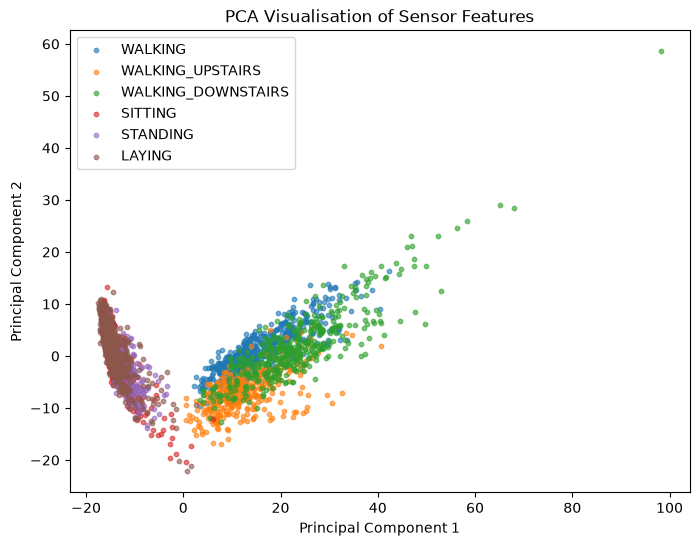

In [21]:
plt.figure(figsize=(8, 6))

for activity in class_order:
    activity_data = pca_plot_df[pca_plot_df["activity"] == activity]
    plt.scatter(
        activity_data["pc1"],
        activity_data["pc2"],
        s=10,
        alpha=0.6,
        label=activity
    )

plt.title("PCA Visualisation of Sensor Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## PCA visualisation note

The PCA plot shows some clear structure in the sensor feature space.

The movement activities, such as walking, walking upstairs, and walking downstairs, appear more spread out on the right side of the plot. Static activities, such as sitting, standing, and laying, appear more concentrated on the left side.

There is still overlap between some classes, especially between similar posture-based activities. This is expected because PCA only compresses the 561-dimensional feature space into two dimensions.

In [22]:
def evaluate_classifier(model, X_data, y_true, model_name):
    y_pred = model.predict(X_data)
    
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    for key, value in result.items():
        if key != "model":
            print(f"{key}: {value:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=class_order,
        zero_division=0
    ))
    
    cm = confusion_matrix(y_true, y_pred, labels=class_order)
    
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_order
    )
    
    fig, ax = plt.subplots(figsize=(8, 8))
    display.plot(ax=ax, xticks_rotation=45)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    
    return result, y_pred

Dummy Baseline
accuracy: 0.1822
balanced_accuracy: 0.1667
macro_f1: 0.0514
weighted_f1: 0.0561

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.00      0.00      0.00       374
  WALKING_UPSTAIRS       0.00      0.00      0.00       311
WALKING_DOWNSTAIRS       0.00      0.00      0.00       285
           SITTING       0.00      0.00      0.00       358
          STANDING       0.00      0.00      0.00       378
            LAYING       0.18      1.00      0.31       380

          accuracy                           0.18      2086
         macro avg       0.03      0.17      0.05      2086
      weighted avg       0.03      0.18      0.06      2086



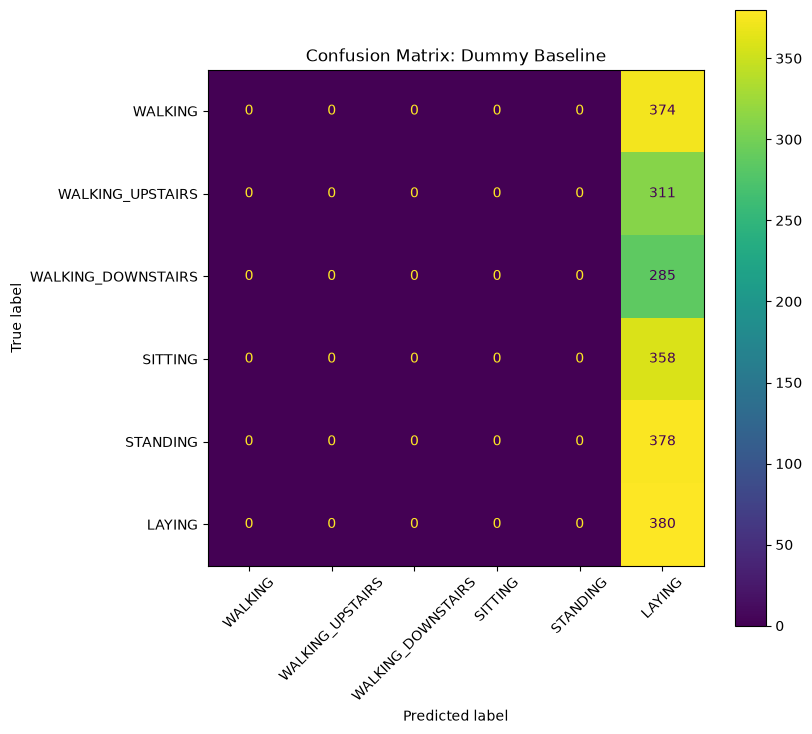

In [23]:
baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_result, baseline_val_preds = evaluate_classifier(
    model=baseline_model,
    X_data=X_val,
    y_true=y_val,
    model_name="Dummy Baseline"
)

## Baseline model 

The dummy baseline achieved:

- Accuracy: 0.1822
- Balanced accuracy: 0.1667
- Macro F1-score: 0.0514
- Weighted F1-score: 0.0561

The baseline predicted only the most common activity class in the training data.

Its very low macro F1-score shows that it is not useful for activity recognition. Any meaningful model should perform much better than this baseline.

Logistic Regression
accuracy: 0.9516
balanced_accuracy: 0.9537
macro_f1: 0.9512
weighted_f1: 0.9514

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.99      0.83      0.90       374
  WALKING_UPSTAIRS       0.84      1.00      0.91       311
WALKING_DOWNSTAIRS       0.98      0.98      0.98       285
           SITTING       0.99      0.93      0.96       358
          STANDING       0.94      0.99      0.96       378
            LAYING       1.00      0.99      1.00       380

          accuracy                           0.95      2086
         macro avg       0.95      0.95      0.95      2086
      weighted avg       0.96      0.95      0.95      2086



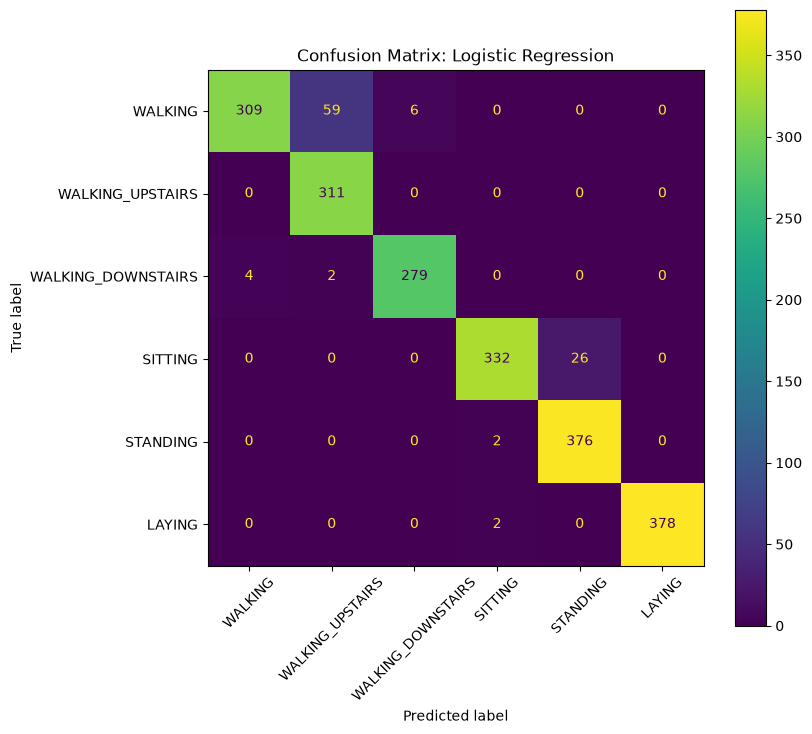

In [24]:
log_reg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

log_reg_model.fit(X_train, y_train)

log_reg_result, log_reg_val_preds = evaluate_classifier(
    model=log_reg_model,
    X_data=X_val,
    y_true=y_val,
    model_name="Logistic Regression"
)

## Logistic regression

Logistic regression achieved the strongest validation performance:

- Accuracy: 0.9516
- Balanced accuracy: 0.9537
- Macro F1-score: 0.9512
- Weighted F1-score: 0.9514

This is a strong result for a linear model.

The high performance suggests that the engineered smartphone sensor features are highly informative and already make the activity classes mostly separable.

PCA + Logistic Regression
accuracy: 0.9219
balanced_accuracy: 0.9240
macro_f1: 0.9225
weighted_f1: 0.9216

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.99      0.85      0.92       374
  WALKING_UPSTAIRS       0.84      0.98      0.90       311
WALKING_DOWNSTAIRS       0.98      0.96      0.97       285
           SITTING       0.95      0.78      0.86       358
          STANDING       0.82      0.97      0.89       378
            LAYING       1.00      0.99      1.00       380

          accuracy                           0.92      2086
         macro avg       0.93      0.92      0.92      2086
      weighted avg       0.93      0.92      0.92      2086



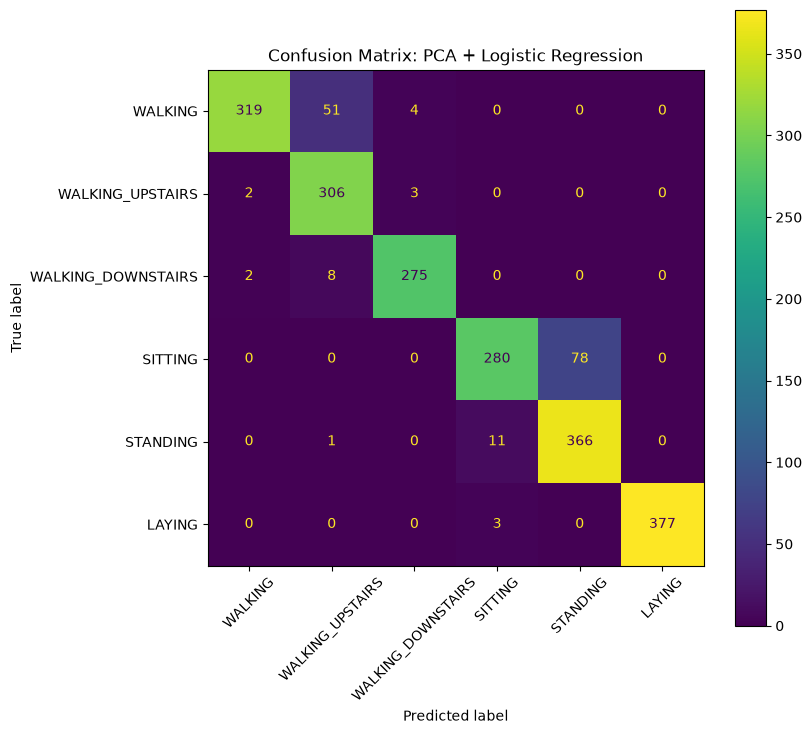

In [25]:
pca_log_reg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

pca_log_reg_model.fit(X_train, y_train)

pca_log_reg_result, pca_log_reg_val_preds = evaluate_classifier(
    model=pca_log_reg_model,
    X_data=X_val,
    y_true=y_val,
    model_name="PCA + Logistic Regression"
)

In [26]:
explained_variance = pca_log_reg_model.named_steps["pca"].explained_variance_ratio_.sum()

print(f"Total variance explained by 50 components: {explained_variance:.2%}")

Total variance explained by 50 components: 87.62%


## PCA logistic regression

PCA + logistic regression achieved:

- Accuracy: 0.9219
- Balanced accuracy: 0.9240
- Macro F1-score: 0.9225
- Weighted F1-score: 0.9216

The 50 PCA components explained 87.62% of the total feature variance.

The model still performed well after dimensionality reduction, but it performed worse than logistic regression using the full feature set. This suggests that PCA preserved much of the information, but some useful classification detail was lost.

Random Forest
accuracy: 0.9338
balanced_accuracy: 0.9369
macro_f1: 0.9340
weighted_f1: 0.9339

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.98      0.77      0.86       374
  WALKING_UPSTAIRS       0.78      0.99      0.87       311
WALKING_DOWNSTAIRS       0.99      0.98      0.99       285
           SITTING       0.96      0.92      0.94       358
          STANDING       0.93      0.97      0.95       378
            LAYING       1.00      0.99      1.00       380

          accuracy                           0.93      2086
         macro avg       0.94      0.94      0.93      2086
      weighted avg       0.94      0.93      0.93      2086



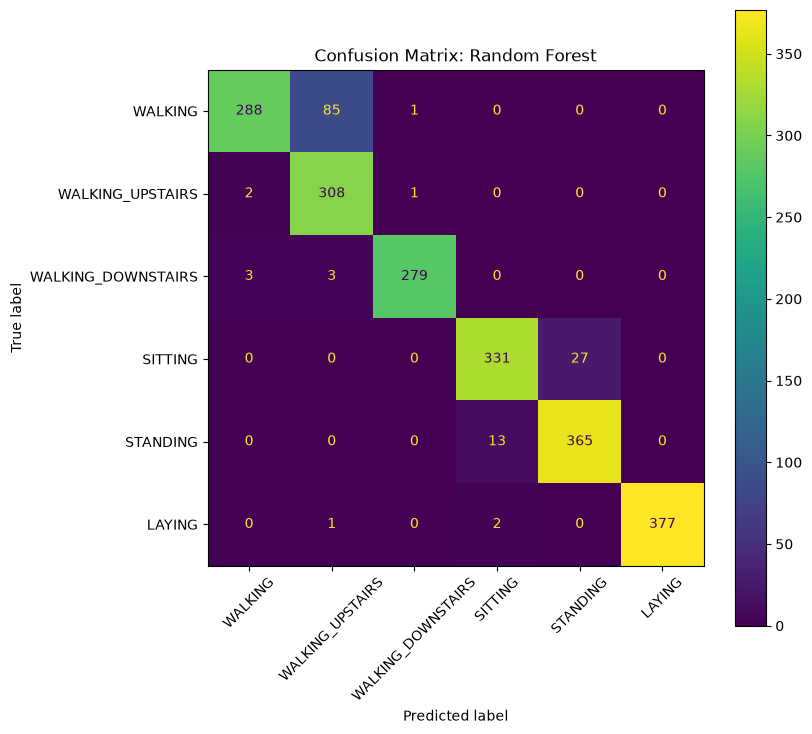

In [27]:
random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_result, rf_val_preds = evaluate_classifier(
    model=random_forest_model,
    X_data=X_val,
    y_true=y_val,
    model_name="Random Forest"
)

## Random forest 

The random forest model achieved:

- Accuracy: 0.9338
- Balanced accuracy: 0.9369
- Macro F1-score: 0.9340
- Weighted F1-score: 0.9339

This was a strong result, but it was still below logistic regression and Extra Trees on the validation set.

The model handled the high-dimensional feature space well, but the engineered sensor features appear to work especially well with linear decision boundaries.

Extra Trees
accuracy: 0.9458
balanced_accuracy: 0.9478
macro_f1: 0.9460
weighted_f1: 0.9459

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.97      0.83      0.90       374
  WALKING_UPSTAIRS       0.82      0.98      0.90       311
WALKING_DOWNSTAIRS       0.99      0.98      0.99       285
           SITTING       0.99      0.91      0.94       358
          STANDING       0.92      0.99      0.95       378
            LAYING       1.00      0.99      1.00       380

          accuracy                           0.95      2086
         macro avg       0.95      0.95      0.95      2086
      weighted avg       0.95      0.95      0.95      2086



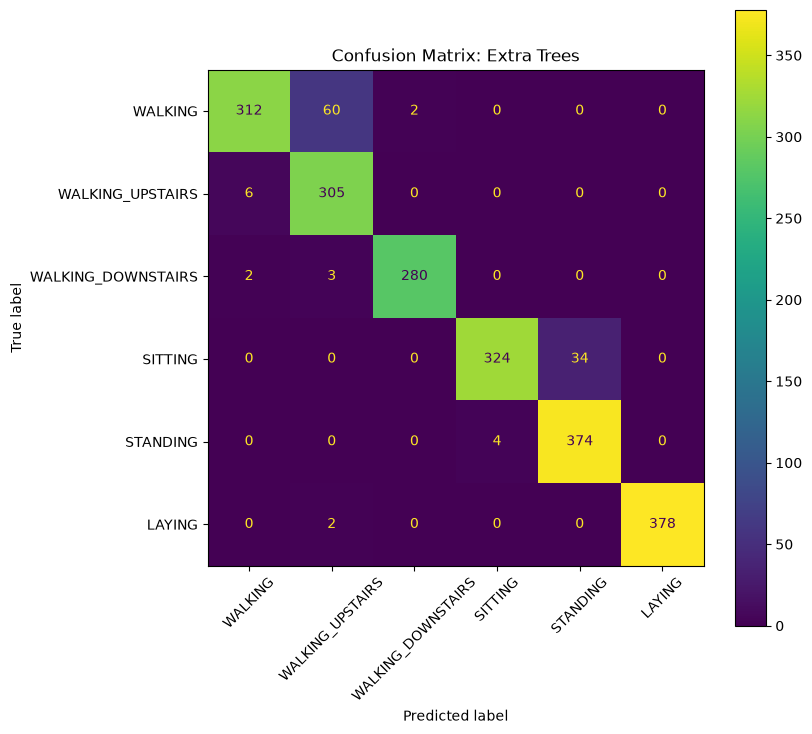

In [28]:
extra_trees_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

extra_trees_model.fit(X_train, y_train)

extra_trees_result, extra_trees_val_preds = evaluate_classifier(
    model=extra_trees_model,
    X_data=X_val,
    y_true=y_val,
    model_name="Extra Trees"
)

## Extra Trees

The Extra Trees model achieved:

- Accuracy: 0.9458
- Balanced accuracy: 0.9478
- Macro F1-score: 0.9460
- Weighted F1-score: 0.9459

Extra Trees was the second-best validation model after logistic regression.

It performed better than random forest, suggesting that the additional randomness in Extra Trees helped generalisation in this high-dimensional sensor feature space.

In [29]:
results_df = pd.DataFrame([
    baseline_result,
    log_reg_result,
    pca_log_reg_result,
    rf_result,
    extra_trees_result
])

results_df.sort_values("macro_f1", ascending=False)

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
1,Logistic Regression,0.951582,0.953662,0.951239,0.951397
4,Extra Trees,0.945829,0.947762,0.946026,0.945937
3,Random Forest,0.933845,0.936942,0.933987,0.933861
2,PCA + Logistic Regression,0.921860,0.924043,0.922467,0.921634
0,Dummy Baseline,0.182167,0.166667,0.051365,0.056142


<Figure size 1000x500 with 0 Axes>

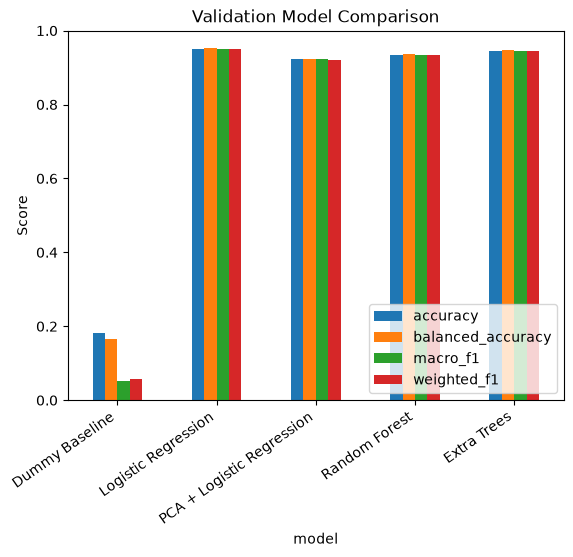

In [30]:
metrics_to_plot = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]

plot_df = results_df.set_index("model")[metrics_to_plot]

plt.figure(figsize=(10, 5))
plot_df.plot(kind="bar")
plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## Validation comparison 

The best validation model was logistic regression.

Validation results:

| Model | Accuracy | Balanced accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.9516 | 0.9537 | 0.9512 | 0.9514 |
| Extra Trees | 0.9458 | 0.9478 | 0.9460 | 0.9459 |
| Random Forest | 0.9338 | 0.9369 | 0.9340 | 0.9339 |
| PCA + Logistic Regression | 0.9219 | 0.9240 | 0.9225 | 0.9216 |
| Dummy Baseline | 0.1822 | 0.1667 | 0.0514 | 0.0561 |

Logistic regression was selected because it achieved the highest validation macro F1-score.

The strong improvement over the dummy baseline confirms that the smartphone sensor features contain meaningful activity information.

In [31]:
model_lookup = {
    "Dummy Baseline": baseline_model,
    "Logistic Regression": log_reg_model,
    "PCA + Logistic Regression": pca_log_reg_model,
    "Random Forest": random_forest_model,
    "Extra Trees": extra_trees_model
}

best_model_name = (
    results_df[results_df["model"] != "Dummy Baseline"]
    .sort_values("macro_f1", ascending=False)
    .iloc[0]["model"]
)

best_model = model_lookup[best_model_name]

print("Best validation model:", best_model_name)

Best validation model: Logistic Regression


Logistic Regression, Test Set
accuracy: 0.8699
balanced_accuracy: 0.8783
macro_f1: 0.8815
weighted_f1: 0.8730

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.95      0.99      0.97       324
  WALKING_UPSTAIRS       0.95      0.93      0.94       315
WALKING_DOWNSTAIRS       0.98      0.95      0.97       283
           SITTING       0.82      0.74      0.78       370
          STANDING       0.65      0.86      0.74       388
            LAYING       1.00      0.79      0.89       395

          accuracy                           0.87      2075
         macro avg       0.89      0.88      0.88      2075
      weighted avg       0.89      0.87      0.87      2075



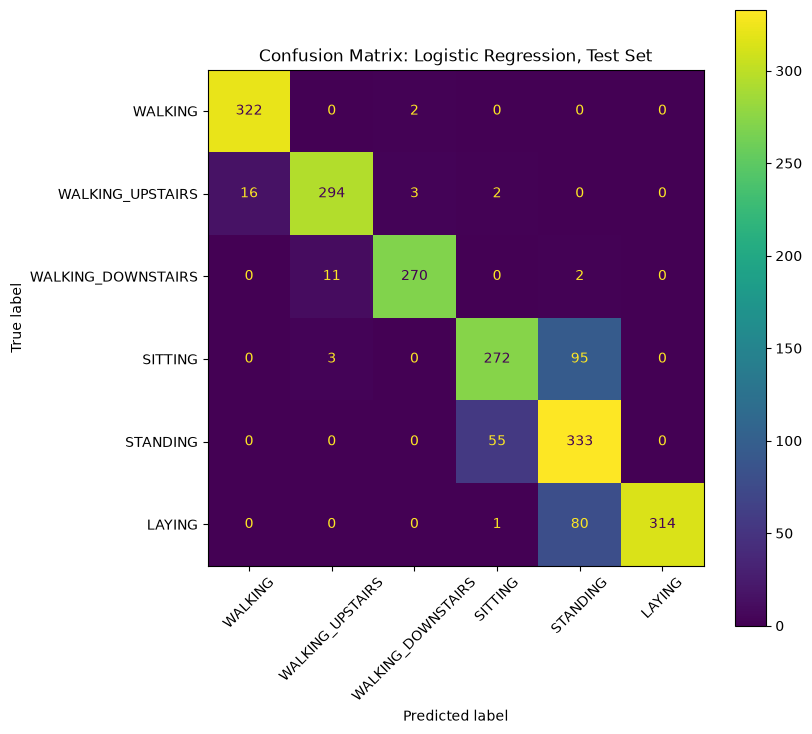

{'model': 'Logistic Regression, Test Set',
 'accuracy': 0.8698795180722891,
 'balanced_accuracy': 0.8782572274572917,
 'macro_f1': 0.8814862293074653,
 'weighted_f1': 0.873031351385656}

In [32]:
test_result, test_preds = evaluate_classifier(
    model=best_model,
    X_data=X_test,
    y_true=y_test,
    model_name=f"{best_model_name}, Test Set"
)

test_result

## Final test result

The selected model was logistic regression.

On the unseen-subject test set, it achieved:

- Accuracy: 0.8699
- Balanced accuracy: 0.8783
- Macro F1-score: 0.8815
- Weighted F1-score: 0.8730

The test performance is lower than the validation performance, which suggests that generalising to completely unseen subjects is harder than the validation result alone suggests.

Even so, the model still performs strongly overall, especially considering that the test subjects were not seen during training.

In [33]:
report_dict = classification_report(
    y_test,
    test_preds,
    labels=class_order,
    output_dict=True,
    zero_division=0
)

class_f1_df = pd.DataFrame([
    {
        "activity": activity,
        "precision": report_dict[activity]["precision"],
        "recall": report_dict[activity]["recall"],
        "f1_score": report_dict[activity]["f1-score"],
        "support": report_dict[activity]["support"]
    }
    for activity in class_order
])

class_f1_df.sort_values("f1_score", ascending=False)

,activity,precision,recall,f1_score,support
0,WALKING,0.952663,0.993827,0.972810,324.0
2,WALKING_DOWNSTAIRS,0.981818,0.954064,0.967742,283.0
1,WALKING_UPSTAIRS,0.954545,0.933333,0.943820,315.0
5,LAYING,1.000000,0.794937,0.885755,395.0
3,SITTING,0.824242,0.735135,0.777143,370.0
4,STANDING,0.652941,0.858247,0.741648,388.0


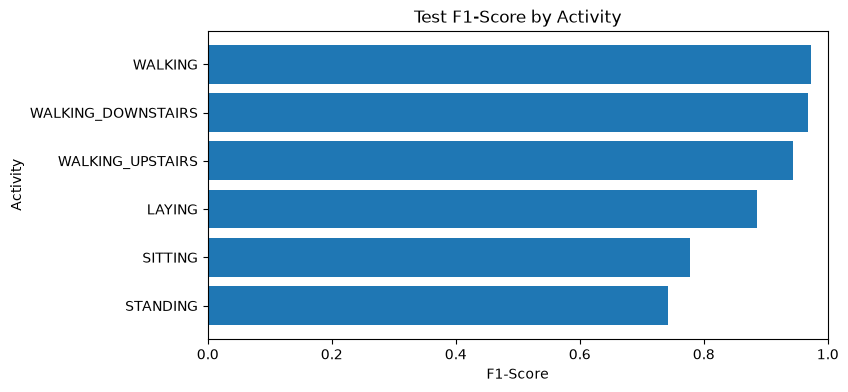

In [34]:
plt.figure(figsize=(8, 4))
plt.barh(
    class_f1_df.sort_values("f1_score")["activity"],
    class_f1_df.sort_values("f1_score")["f1_score"]
)
plt.title("Test F1-Score by Activity")
plt.xlabel("F1-Score")
plt.ylabel("Activity")
plt.xlim(0, 1)
plt.show()

## Per-class performance

The easiest activities on the test set were:

- WALKING, with an F1-score of 0.9728
- WALKING_DOWNSTAIRS, with an F1-score of 0.9677
- WALKING_UPSTAIRS, with an F1-score of 0.9438
- LAYING, with an F1-score of 0.8858

The hardest activities were:

- SITTING, with an F1-score of 0.7771
- STANDING, with an F1-score of 0.7416

The model is very strong at recognising dynamic walking activities, but it struggles more with static posture activities, especially sitting and standing.

In [35]:
cm = confusion_matrix(y_test, test_preds, labels=class_order)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {label}" for label in class_order],
    columns=[f"Predicted: {label}" for label in class_order]
)

cm_df

,Predicted: WALKING,Predicted: WALKING_UPSTAIRS,Predicted: WALKING_DOWNSTAIRS,Predicted: SITTING,Predicted: STANDING,Predicted: LAYING
Actual: WALKING,322,0,2,0,0,0
Actual: WALKING_UPSTAIRS,16,294,3,2,0,0
Actual: WALKING_DOWNSTAIRS,0,11,270,0,2,0
Actual: SITTING,0,3,0,272,95,0
Actual: STANDING,0,0,0,55,333,0
Actual: LAYING,0,0,0,1,80,314


In [36]:
confusion_pairs = []

for i, actual in enumerate(class_order):
    for j, predicted in enumerate(class_order):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "actual": actual,
                "predicted": predicted,
                "count": cm[i, j]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs).sort_values(
    "count",
    ascending=False
)

confusion_pairs_df.head(10)

,actual,predicted,count
7,SITTING,STANDING,95
10,LAYING,STANDING,80
8,STANDING,SITTING,55
1,WALKING_UPSTAIRS,WALKING,16
4,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,11
6,SITTING,WALKING_UPSTAIRS,3
2,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,3
0,WALKING,WALKING_DOWNSTAIRS,2
3,WALKING_UPSTAIRS,SITTING,2
5,WALKING_DOWNSTAIRS,STANDING,2


## Confusion analysis

The most common confusion was:

SITTING → STANDING, with 95 cases.

Other major confusions were:

- LAYING → STANDING, with 80 cases
- STANDING → SITTING, with 55 cases
- WALKING_UPSTAIRS → WALKING, with 16 cases
- WALKING_DOWNSTAIRS → WALKING_UPSTAIRS, with 11 cases

This makes sense because sitting, standing, and laying are all low-motion activities, so their sensor patterns can be more similar than walking activities.

The confusion matrix shows that the model is very reliable for movement activities, but less reliable when separating similar static body postures.

In [37]:
feature_importance_model = extra_trees_model

feature_names = X_train.columns

importances = feature_importance_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
52,tGravityAcc-min()-X,0.026204
56,tGravityAcc-energy()-X,0.025669
49,tGravityAcc-max()-X,0.025343
50,tGravityAcc-max()-Y,0.024413
40,tGravityAcc-mean()-X,0.023627
559,"angle(Y,gravityMean)",0.022779
41,tGravityAcc-mean()-Y,0.022657
53,tGravityAcc-min()-Y,0.021756
558,"angle(X,gravityMean)",0.020736
57,tGravityAcc-energy()-Y,0.018774


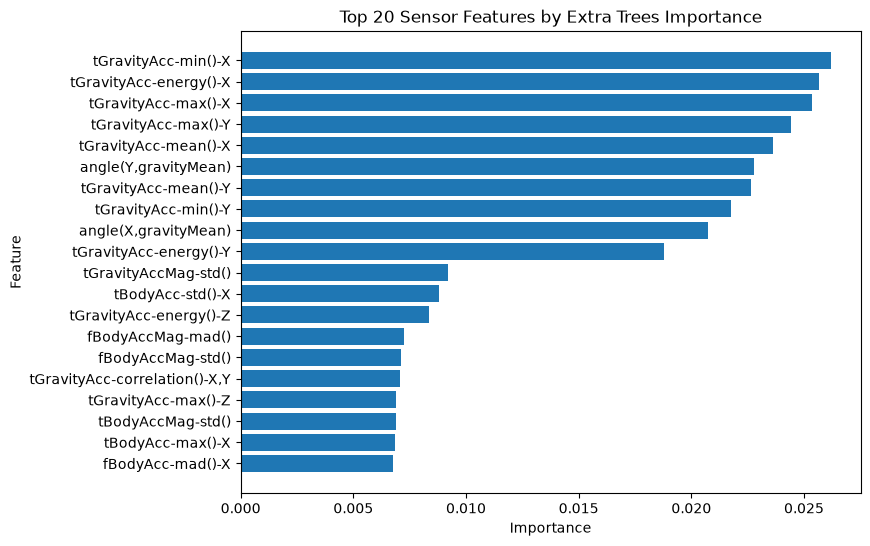

In [38]:
top_features = importance_df.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 20 Sensor Features by Extra Trees Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Feature importance 

The most important individual features from the Extra Trees model were mostly related to gravity acceleration and body orientation.

The top features included:

- tGravityAcc-min()-X
- tGravityAcc-energy()-X
- tGravityAcc-max()-X
- tGravityAcc-max()-Y
- tGravityAcc-mean()-X
- angle(Y,gravityMean)
- tGravityAcc-mean()-Y
- angle(X,gravityMean)

This suggests that body orientation and gravity-related signals are highly useful for distinguishing activities, especially static postures such as sitting, standing, and laying.

In [39]:
def feature_family(feature_name):
    if feature_name.startswith("tBodyAcc"):
        return "Time body acceleration"
    if feature_name.startswith("tGravityAcc"):
        return "Time gravity acceleration"
    if feature_name.startswith("tBodyGyro"):
        return "Time body gyroscope"
    if feature_name.startswith("tBodyAccJerk"):
        return "Time body acceleration jerk"
    if feature_name.startswith("tBodyGyroJerk"):
        return "Time body gyroscope jerk"
    if feature_name.startswith("fBodyAcc"):
        return "Frequency body acceleration"
    if feature_name.startswith("fBodyGyro"):
        return "Frequency body gyroscope"
    if feature_name.startswith("fBodyBodyAccJerk"):
        return "Frequency body acceleration jerk"
    if feature_name.startswith("fBodyBodyGyroJerk"):
        return "Frequency body gyroscope jerk"
    if feature_name.startswith("angle"):
        return "Angle features"
    return "Other"


importance_df["feature_family"] = importance_df["feature"].apply(feature_family)

family_importance_df = (
    importance_df
    .groupby("feature_family")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

family_importance_df

,feature_family,importance
0,Time gravity acceleration,0.330837
1,Frequency body acceleration,0.222215
2,Time body acceleration,0.171959
3,Time body gyroscope,0.110055
4,Frequency body gyroscope,0.071629
5,Angle features,0.049852
6,Frequency body acceleration jerk,0.022670
7,Frequency body gyroscope jerk,0.012019
8,Other,0.008765


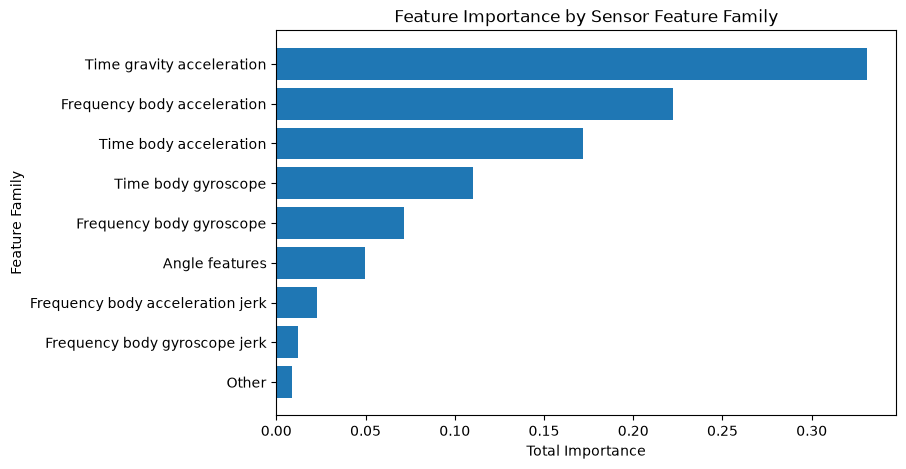

In [40]:
plt.figure(figsize=(8, 5))
plt.barh(
    family_importance_df["feature_family"][::-1],
    family_importance_df["importance"][::-1]
)
plt.title("Feature Importance by Sensor Feature Family")
plt.xlabel("Total Importance")
plt.ylabel("Feature Family")
plt.show()

## Feature family importance

The most important feature families were:

1. Time gravity acceleration: 0.3308
2. Frequency body acceleration: 0.2222
3. Time body acceleration: 0.1720
4. Time body gyroscope: 0.1101
5. Frequency body gyroscope: 0.0716
6. Angle features: 0.0499

This shows that both orientation-related features and motion-related features contributed to classification.

Gravity acceleration was the most important family overall, which makes sense because body orientation is highly relevant for separating sitting, standing, and laying.

In [41]:
pca_summary = pd.DataFrame({
    "model": ["Logistic Regression", "PCA + Logistic Regression"],
    "validation_macro_f1": [
        log_reg_result["macro_f1"],
        pca_log_reg_result["macro_f1"]
    ],
    "validation_accuracy": [
        log_reg_result["accuracy"],
        pca_log_reg_result["accuracy"]
    ]
})

pca_summary

,model,validation_macro_f1,validation_accuracy
0,Logistic Regression,0.951239,0.951582
1,PCA + Logistic Regression,0.922467,0.921860


## PCA comparison 

The full logistic regression model achieved:

- Validation accuracy: 0.9516
- Validation macro F1-score: 0.9512

The PCA + logistic regression model achieved:

- Validation accuracy: 0.9219
- Validation macro F1-score: 0.9225

This shows that PCA compression reduced performance in this experiment.

Although 50 components captured 87.62% of the variance, the full 561-feature representation still preserved more useful information for activity classification.

In [42]:
final_summary_df = pd.DataFrame([
    baseline_result,
    log_reg_result,
    pca_log_reg_result,
    rf_result,
    extra_trees_result,
    test_result
])

final_summary_df

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Dummy Baseline,0.182167,0.166667,0.051365,0.056142
1,Logistic Regression,0.951582,0.953662,0.951239,0.951397
2,PCA + Logistic Regression,0.921860,0.924043,0.922467,0.921634
3,Random Forest,0.933845,0.936942,0.933987,0.933861
4,Extra Trees,0.945829,0.947762,0.946026,0.945937
5,"Logistic Regression, Test Set",0.869880,0.878257,0.881486,0.873031


In [43]:
print("Best validation model:", best_model_name)
print()
print("Final test performance:")
print(f"Accuracy:          {test_result['accuracy']:.4f}")
print(f"Balanced accuracy: {test_result['balanced_accuracy']:.4f}")
print(f"Macro F1-score:    {test_result['macro_f1']:.4f}")
print(f"Weighted F1-score: {test_result['weighted_f1']:.4f}")

Best validation model: Logistic Regression

Final test performance:
Accuracy:          0.8699
Balanced accuracy: 0.8783
Macro F1-score:    0.8815
Weighted F1-score: 0.8730
